In [1]:
%load_ext autoreload
%autoreload 2
%autosave 30

Autosaving every 30 seconds


# Plot Scores
In this notebook we will investigate the scores of the models across different leadtimes

In [2]:
import json

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

import wandb

In [3]:
api = wandb.Api()

# Get runs with a specific tag
runs = api.runs(
    "feik/genpp",  # Replace with your entity/project
    filters={"tags": {"$all": ["best", "multi leadtime"], "$nin": ["deprecated"]}},
)

In [4]:
def parse_wandb_runs_to_polars(runs):
    """
    Parse WandB runs into a Polars DataFrame.
    Handles nested metrics with optional method keys (ECC, GCA, etc.)
    """
    rows = []

    for run in runs:
        run_id = run.id
        try:
            val_metrics = run.summary._json_dict["val"]
        except KeyError:
            print(f"Run {run_id} has no 'val' metrics, skipping.")
            continue
        json_config = json.loads(run.json_config)
        model_name = json_config["name"]["value"]
        # Check if metrics have method level (ECC, GCA) or not
        if any(key in val_metrics for key in ["ECC", "GCA"]):
            # Has method level (like EMOS, DRN)
            for method, method_metrics in val_metrics.items():
                if not isinstance(method_metrics, dict):
                    continue  # Skip non-dict values
                for metric_name, time_values in method_metrics.items():
                    if not isinstance(time_values, dict):
                        continue  # Skip non-dict values
                    for time_horizon, value in time_values.items():
                        # Convert time_horizon string (e.g., "24h") to hours integer
                        hours = int(time_horizon.rstrip("h"))
                        rows.append(
                            {
                                "run_id": run_id,
                                "model_name": model_name,
                                "method": method,
                                "metric_name": metric_name,
                                "timedelta_hours": hours,
                                "value": value,
                            }
                        )
        else:
            # No method level (like FM_UNET, CHEN and ENGRESSION)
            if model_name == "CHEN_SPATIAL":
                model_name += "_" + str(json_config["model.loss_fn.patch_size"]["value"])
            elif model_name in ("FM_UVIT", "FM_UNET"):
                model_name += "_" + str(json_config["model.internal_td_scaling"]["value"])
            for metric_name, time_values in val_metrics.items():
                if not isinstance(time_values, dict):
                    continue  # Skip non-dict values (like _wandb metadata)
                for time_horizon, value in time_values.items():
                    # Convert time_horizon string (e.g., "24h") to hours integer
                    hours = int(time_horizon.rstrip("h"))
                    rows.append(
                        {
                            "run_id": run_id,
                            "model_name": model_name,
                            "method": None,
                            "metric_name": metric_name,
                            "timedelta_hours": hours,
                            "value": value,
                        }
                    )
    # Create Polars DataFrame with explicit Duration type
    df = (
        pl.DataFrame(rows)
        .with_columns(
            pl.col("timedelta_hours").mul(3600_000_000).cast(pl.Duration("us")).alias("timedelta")
        )
        .drop("timedelta_hours")
    )

    return df


df = parse_wandb_runs_to_polars(runs)
df

run_id,model_name,method,metric_name,value,timedelta
str,str,str,str,f64,duration[μs]
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.698839,5d
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.37776,1d
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.444331,2d
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.519051,3d
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.614189,4d
…,…,…,…,…,…
"""2f1vpjz0""","""CHEN""",null,"""VariogramScore_combined""",665545.5,5d
"""2f1vpjz0""","""CHEN""",null,"""VariogramScore_combined""",355862.4375,1d
"""2f1vpjz0""","""CHEN""",null,"""VariogramScore_combined""",420969.21875,2d


In [5]:
# Prepare data for plotting using polars
df_plot = df.with_columns(
    [
        # Create combined model+method label
        pl.when(pl.col("method").is_null())
        .then(pl.col("model_name"))
        .otherwise(pl.col("model_name") + " (" + pl.col("method") + ")")
        .alias("model_method"),
        # Convert timedelta to days for better readability
        (pl.col("timedelta").dt.total_days()).alias("days"),
        # Split metric_name into score and variable
        pl.col("metric_name").str.split("_").list.first().alias("score"),
        pl.col("metric_name").str.split("_").list.slice(1).list.join("_").alias("variable"),
    ]
).sort(["score", "variable", "model_method", "days"])

df_plot

run_id,model_name,method,metric_name,value,timedelta,model_method,days,score,variable
str,str,str,str,f64,duration[μs],str,i64,str,str
"""2f1vpjz0""","""CHEN""",null,"""CRPS_10m_windspeed""",0.395176,1d,"""CHEN""",1,"""CRPS""","""10m_windspeed"""
"""2f1vpjz0""","""CHEN""",null,"""CRPS_10m_windspeed""",0.461864,2d,"""CHEN""",2,"""CRPS""","""10m_windspeed"""
"""2f1vpjz0""","""CHEN""",null,"""CRPS_10m_windspeed""",0.543199,3d,"""CHEN""",3,"""CRPS""","""10m_windspeed"""
"""2f1vpjz0""","""CHEN""",null,"""CRPS_10m_windspeed""",0.648023,4d,"""CHEN""",4,"""CRPS""","""10m_windspeed"""
"""2f1vpjz0""","""CHEN""",null,"""CRPS_10m_windspeed""",0.743374,5d,"""CHEN""",5,"""CRPS""","""10m_windspeed"""
…,…,…,…,…,…,…,…,…,…
"""utgo5npv""","""Raw Ensemble""",null,"""VariogramScore_combined""",378034.40625,1d,"""Raw Ensemble""",1,"""VariogramScore""","""combined"""
"""utgo5npv""","""Raw Ensemble""",null,"""VariogramScore_combined""",439132.09375,2d,"""Raw Ensemble""",2,"""VariogramScore""","""combined"""
"""utgo5npv""","""Raw Ensemble""",null,"""VariogramScore_combined""",503419.78125,3d,"""Raw Ensemble""",3,"""VariogramScore""","""combined"""


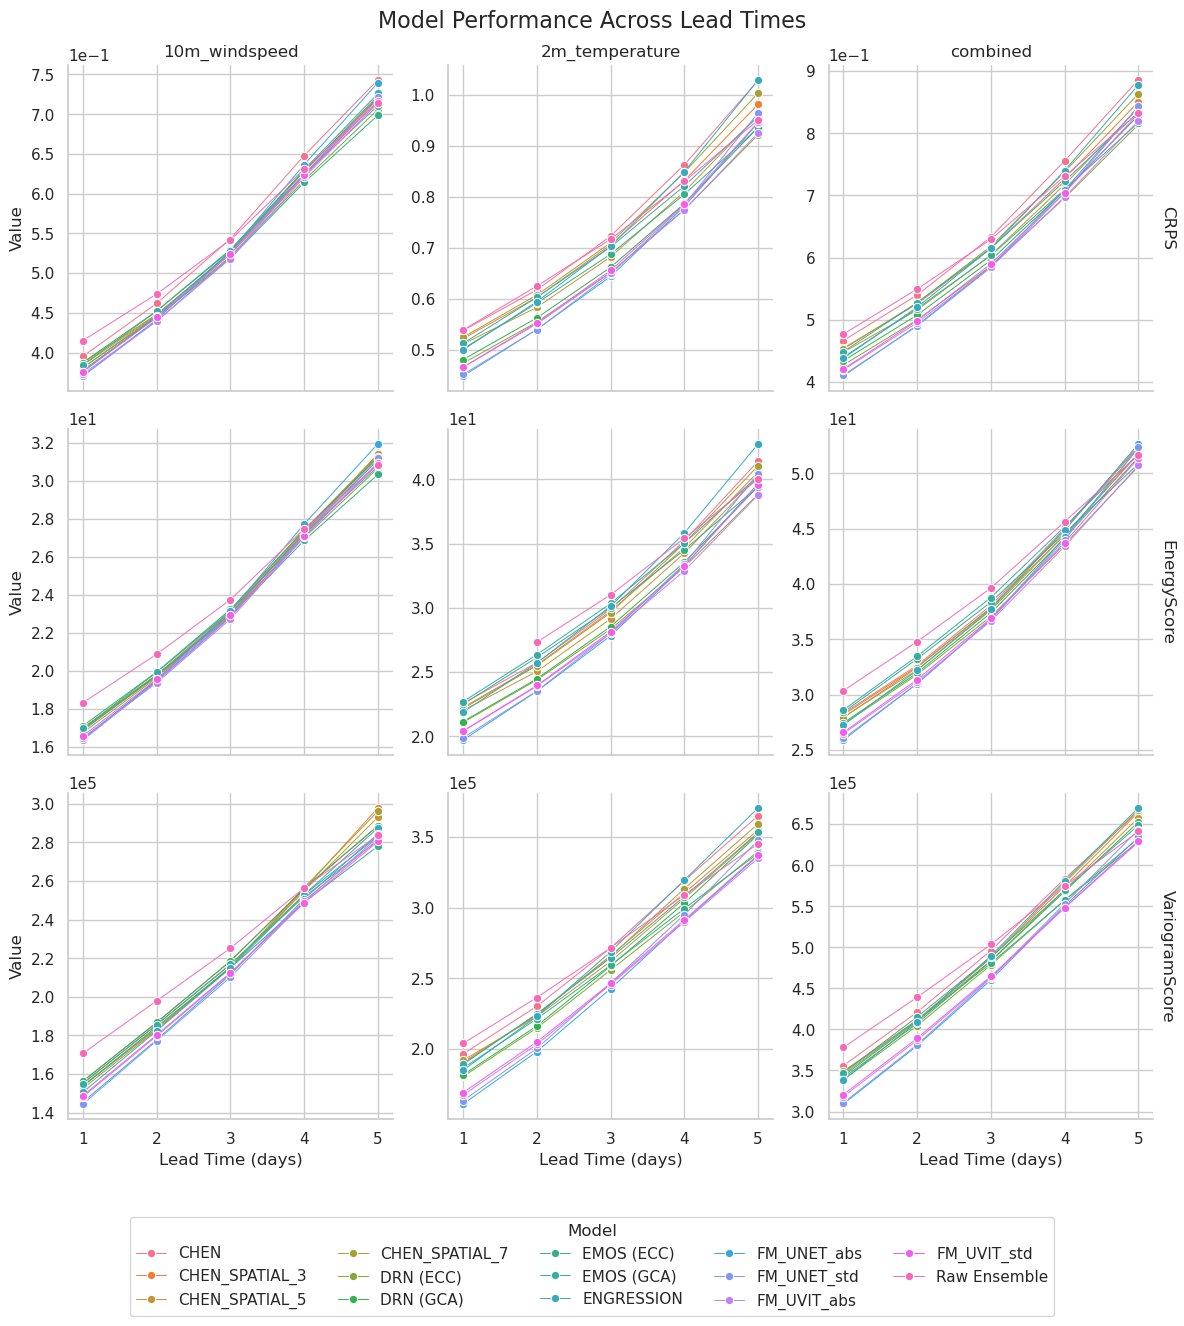

In [11]:
# Set seaborn style
sns.set_theme(style="whitegrid")
sns.set_palette("husl")  # Use tab10 colormap

# Convert to pandas for seaborn FacetGrid (works better with pandas)
df_pandas = df_plot.to_pandas()

# Get unique scores and variables to determine grid layout
n_scores = df_pandas["score"].nunique()
n_variables = df_pandas["variable"].nunique()

# Create FacetGrid with score as rows and variable as columns
g = sns.FacetGrid(
    df_pandas,
    col="variable",
    row="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Plot lines for each model+method
g.map_dataframe(
    sns.lineplot,
    x="days",
    y="value",
    hue="model_method",
    style="model_method",
    marker="o",
    linewidth=0.7,
    dashes=False,
)

# Format y-axes with scientific notation for large numbers
for ax in g.axes.flat:
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Add legend below the plot with multiple columns
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(
    handles, labels, title="Model", bbox_to_anchor=(0.5, -0.02), loc="upper center", ncol=5
)

# Set labels
g.set_axis_labels("Lead Time (days)", "Value")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.subplots_adjust(top=0.95)
g.figure.suptitle("Model Performance Across Lead Times", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
from bokeh.io import output_notebook, show
from bokeh.layouts import column, gridplot
from bokeh.models import ColumnDataSource, HoverTool, Range1d
from bokeh.plotting import figure

output_notebook()

# Get unique values for grid layout
scores = df_pandas["score"].unique()
variables = df_pandas["variable"].unique()
model_methods = df_pandas["model_method"].unique()

# Use seaborn's husl palette and convert to hex colors for bokeh
husl_colors = sns.color_palette("husl", n_colors=len(model_methods))
colors = [f"#{int(r * 255):02x}{int(g * 255):02x}{int(b * 255):02x}" for r, g, b in husl_colors]
color_map = {model: colors[i] for i, model in enumerate(model_methods)}

# Create shared x_range for linked panning/zooming
shared_x_range = None

# Create grid of plots with linked axes
plots = []

for i, score in enumerate(scores):
    row_plots = []
    for j, variable in enumerate(variables):
        # Filter data for this subplot
        subset = df_pandas[(df_pandas["score"] == score) & (df_pandas["variable"] == variable)]

        # Create figure with linked x_range
        if shared_x_range is None:
            p = figure(
                title=f"{score} - {variable}",
                x_axis_label="Lead Time (days)" if i == len(scores) - 1 else None,
                y_axis_label="Value",
                width=400,
                height=300,
                tools="pan,wheel_zoom,box_zoom,reset,save",
            )
            shared_x_range = p.x_range
        else:
            p = figure(
                title=f"{score} - {variable}",
                x_axis_label="Lead Time (days)" if i == len(scores) - 1 else None,
                y_axis_label="Value",
                width=400,
                height=300,
                tools="pan,wheel_zoom,box_zoom,reset,save",
                x_range=shared_x_range,  # Link x-axis
            )

        for model_method in model_methods:
            model_data = subset[subset["model_method"] == model_method].sort_values("days")
            if len(model_data) == 0:
                continue

            source = ColumnDataSource(model_data)

            line = p.line(
                x="days",
                y="value",
                source=source,
                color=color_map[model_method],
                line_width=1.5,
                alpha=0.75,
                legend_label=model_method,
            )
            circle = p.scatter(
                x="days",
                y="value",
                source=source,
                color=color_map[model_method],
                size=8,
                alpha=0.8,
            )

        # Add hover tool
        hover = HoverTool(
            tooltips=[
                ("Model", "@model_method"),
                ("Days", "@days"),
                ("Value", "@value{0.000}"),
            ]
        )
        p.add_tools(hover)

        # Hide individual legends - we'll create a shared one
        p.legend.visible = False

        row_plots.append(p)
    plots.append(row_plots)

# Create a single legend figure spanning full width
legend_fig = figure(
    height=50,
    toolbar_location=None,
    outline_line_color=None,
    sizing_mode="stretch_width",
)
legend_fig.axis.visible = False
legend_fig.grid.visible = False

# Add invisible glyphs to create legend entries
for model_method in model_methods:
    legend_fig.line(
        x=[0],
        y=[0],
        color=color_map[model_method],
        line_width=2,
        legend_label=model_method,
    )
    legend_fig.scatter(
        x=[0],
        y=[0],
        color=color_map[model_method],
        size=8,
        legend_label=model_method,
    )

# Configure the legend
legend_fig.legend.orientation = "horizontal"
legend_fig.legend.location = "center"
legend_fig.legend.click_policy = "hide"
legend_fig.legend.label_text_font_size = "10pt"
legend_fig.legend.spacing = 10
legend_fig.legend.nrows = 2

# Hide the plot area of legend figure
legend_fig.x_range = Range1d(0, 0)
legend_fig.y_range = Range1d(0, 0)

# Create grid layout and add legend below
grid = gridplot(plots, sizing_mode="stretch_width")
layout = column(grid, legend_fig, sizing_mode="stretch_both")
show(layout)

Loading BokehJS ...